In [1]:
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import sys, json, math, random, gc, time
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

try:
    import segmentation_models_pytorch as smp
except ImportError as e:
    raise ImportError("Run: pip install segmentation-models-pytorch") from e

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

print("Using device:", DEVICE)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.cuda.empty_cache()
    free, total = torch.cuda.mem_get_info()
    print(f"GPU: {torch.cuda.get_device_name(0)} | free/total: {free/1e9:.2f}/{total/1e9:.2f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU | free/total: 6.40/8.18 GB


In [2]:
# ----------------------------- PATHS -----------------------------------
# Notebook location: Segmentation with Annotation/UNET++/spectral_model.ipynb
SPECTRAL_MODULE_DIR = os.path.join("..", "..", "Data Analysis")
IMAGES_DIR = os.path.join("..", "..", "Data Analytics", "Google_MapStaticAPI", "images")
ANNOTATIONS_JSON = os.path.join("..", "..", "Data Analytics", "Annotation", "Solar Images", "annotations", "merged_instances_default.json")
USE_MASK_FOLDER = False
MASKS_DIR = os.path.join("..", "masks")

CHECKPOINT_PATH = os.path.join(".", "outputs", "models", "unet_best.pth")

RUN_NAME = "v2"
OUTPUT_DIR = os.path.join(".", "outputs")
MODELS_DIR = os.path.join(OUTPUT_DIR, "models")
SPECTRAL_RESULTS_DIR = os.path.join(OUTPUT_DIR, "spectral_analysis")
METRICS_DIR = os.path.join(SPECTRAL_RESULTS_DIR, "metrics")
VIS_DIR = os.path.join(SPECTRAL_RESULTS_DIR, "visualizations")
for d in (MODELS_DIR, METRICS_DIR, VIS_DIR):
    os.makedirs(d, exist_ok=True)

FINETUNED_CKPT = os.path.join(MODELS_DIR, f"unet_best_spectral_{RUN_NAME}.pth")
SPLIT_JSON = os.path.join(SPECTRAL_RESULTS_DIR, "split.json")

# ------------------- ARCHITECTURE --------------------------------------
ENCODER_NAME = "resnet34"
NUM_CLASSES = 1
IMG_SIZE = 512
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

# ------------------------ SHADOW-CHANNEL STRATEGY -----------------------
USE_SHADOW_CHANNEL = True
SHADOW_CHANNEL_INIT_SCALE = 0.1
SHADOW_AUGMENT_PROB = 0.5
SHADOW_LOSS_WEIGHT = 2.0

# ------------------------------ SPLITS ----------------------------------
VAL_SPLIT = 0.15
TEST_SPLIT = 0.10

# ---------------------------- TRAINING ----------------------------------
USE_AMP = DEVICE.type == "cuda"
BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 4
EVAL_BATCH_SIZE = 8
NUM_WORKERS = 2
NUM_EPOCHS = 40
LR_ENCODER = 1e-4
LR_DECODER = 5e-4
WEIGHT_DECAY = 1e-4
PCT_START = 0.15
GRAD_CLIP = 1.0
FREEZE_ENCODER_EPOCHS = 2
EARLY_STOP_PATIENCE = 10

# ---------------------------- EVALUATION --------------------------------
PRED_THRESHOLD = 0.5
MIN_INSTANCE_AREA_PX = 16
EVAL_BASELINE_SPLITS = ("val", "test")

In [3]:
if SPECTRAL_MODULE_DIR not in sys.path:
    sys.path.append(SPECTRAL_MODULE_DIR)
import spectral_analysis as sa
cfg = sa.SpectralConfig()

if not USE_MASK_FOLDER:
    images_by_id, anns_by_image_id, categories = sa.load_coco_annotations(ANNOTATIONS_JSON)
else:
    image_files = sorted(f for f in os.listdir(IMAGES_DIR) if f.lower().endswith((".png", ".jpg", ".jpeg")))
    images_by_id = {i: {"file_name": f, "id": i} for i, f in enumerate(image_files)}
    anns_by_image_id = None

def load_gt_mask_for(image_id):
    info = images_by_id[image_id]
    rgb = sa.load_image(os.path.join(IMAGES_DIR, info["file_name"]))
    h, w = rgb.shape[:2]
    if USE_MASK_FOLDER:
        mask_name = os.path.splitext(info["file_name"])[0] + ".png"
        gt = sa.load_mask_folder_annotation(os.path.join(MASKS_DIR, mask_name))
    else:
        gt = sa.ground_truth_mask_for_image(image_id, anns_by_image_id, h, w)
    return rgb, gt

all_ids = sorted(images_by_id.keys())
if os.path.exists(SPLIT_JSON):
    with open(SPLIT_JSON) as f:
        split = json.load(f)
    valid = set(all_ids)
    train_ids = [i for i in split["train"] if i in valid]
    val_ids = [i for i in split["val"] if i in valid]
    test_ids = [i for i in split["test"] if i in valid]
    print("Loaded existing split from", SPLIT_JSON)
else:
    random.Random(SEED).shuffle(all_ids)
    n_val = int(len(all_ids) * VAL_SPLIT)
    n_test = int(len(all_ids) * TEST_SPLIT)
    val_ids = all_ids[:n_val]
    test_ids = all_ids[n_val:n_val + n_test]
    train_ids = all_ids[n_val + n_test:]
    with open(SPLIT_JSON, "w") as f:
        json.dump({"train": train_ids, "val": val_ids, "test": test_ids}, f)
    print("Created new split ->", SPLIT_JSON)
print(f"train: {len(train_ids)} | val: {len(val_ids)} | test: {len(test_ids)}")

Loaded existing split from ./outputs/spectral_analysis/split.json
train: 1875 | val: 375 | test: 250


In [4]:
def build_model(in_channels=3):
    return smp.UnetPlusPlus(
        encoder_name=ENCODER_NAME, encoder_weights=None,
        in_channels=in_channels, classes=NUM_CLASSES, activation=None,
    )


def inflate_first_conv_to_n_channels(model, n_channels, init_scale=0.1):
    target_name, target_module = None, None
    for name, module in model.encoder.named_modules():
        if isinstance(module, nn.Conv2d):
            target_name, target_module = name, module
            break
    if target_module is None:
        raise RuntimeError("No Conv2d found in model.encoder")
    parts = target_name.split(".")
    parent = model.encoder
    for p in parts[:-1]:
        parent = getattr(parent, p)
    old = target_module
    if old.in_channels == n_channels:
        return model
    new = nn.Conv2d(n_channels, old.out_channels, kernel_size=old.kernel_size,
                    stride=old.stride, padding=old.padding, bias=(old.bias is not None))
    with torch.no_grad():
        new.weight[:, :old.in_channels] = old.weight
        mean_filter = old.weight.mean(dim=1, keepdim=True) * init_scale
        for c in range(n_channels - old.in_channels):
            new.weight[:, old.in_channels + c: old.in_channels + c + 1] = mean_filter
        if old.bias is not None:
            new.bias[:] = old.bias
    setattr(parent, parts[-1], new)
    print(f"Inflated '{target_name}': {old.in_channels} -> {n_channels} channels")
    return model

model = build_model(in_channels=3)
ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu")
state_dict = ckpt.get("model_state_dict", ckpt) if isinstance(ckpt, dict) else ckpt
missing, unexpected = model.load_state_dict(state_dict, strict=False)
print(f"Checkpoint loaded: {len(missing)} missing / {len(unexpected)} unexpected keys")
if len(missing) > 5 or len(unexpected) > 5:
    print("WARNING: large mismatch -> ENCODER_NAME / NUM_CLASSES in Cell 3 are probably wrong.")
if USE_SHADOW_CHANNEL:
    model = inflate_first_conv_to_n_channels(model, 4, SHADOW_CHANNEL_INIT_SCALE)
    IN_CHANNELS = 4
else:
    IN_CHANNELS = 3
model = model.to(DEVICE)
print(f"Model ready on {DEVICE} | {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M parameters | input channels: {IN_CHANNELS}")

Checkpoint loaded: 292 missing / 182 unexpected keys
Inflated 'conv1': 3 -> 4 channels
Model ready on cuda | 26.1M parameters | input channels: 4


/tmp/ipykernel_214268/2297100446.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu")


In [5]:
def synthetic_shadow_on_panel(rgb, gt_mask, darken=(0.45, 0.75), blue_shift=1.15):
    ys, xs = np.where(gt_mask == 1)
    if len(ys) == 0:
        return rgb
    idx = np.random.randint(len(ys))
    cy, cx = int(ys[idx]), int(xs[idx])
    h, w = rgb.shape[:2]
    rad_y = np.random.randint(max(4, h // 30), max(6, h // 8))
    rad_x = np.random.randint(max(4, w // 30), max(6, w // 8))
    patch = np.zeros((h, w), dtype=np.uint8)
    cv2.ellipse(patch, (cx, cy), (rad_x, rad_y), 0, 0, 360, 1, thickness=-1)
    out = rgb.astype(np.float32)
    f = np.random.uniform(*darken)
    out[patch == 1, 0] *= f
    out[patch == 1, 1] *= f
    out[patch == 1, 2] *= min(f * blue_shift, 1.0)
    return np.clip(out, 0, 255).astype(np.uint8)


def random_geometric(rgb, gt):
    if np.random.rand() < 0.5:
        rgb, gt = rgb[:, ::-1], gt[:, ::-1]
    if np.random.rand() < 0.5:
        rgb, gt = rgb[::-1], gt[::-1]
    k = np.random.randint(4)
    if k:
        rgb, gt = np.rot90(rgb, k), np.rot90(gt, k)
    return np.ascontiguousarray(rgb), np.ascontiguousarray(gt)


class SolarShadowDataset(Dataset):
    def __init__(self, sample_ids, img_size, cfg, use_shadow_channel=True,
                 correct_shadow=True, geo_augment=False, shadow_augment_prob=0.0):
        self.sample_ids = list(sample_ids)
        self.img_size = img_size
        self.cfg = cfg
        self.use_shadow_channel = use_shadow_channel
        self.correct_shadow = correct_shadow
        self.geo_augment = geo_augment
        self.shadow_augment_prob = shadow_augment_prob

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        rgb, gt = load_gt_mask_for(self.sample_ids[idx])
        rgb = cv2.resize(rgb, (self.img_size, self.img_size), interpolation=cv2.INTER_AREA)
        gt = cv2.resize(gt, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
        if self.geo_augment:
            rgb, gt = random_geometric(rgb, gt)
        if self.shadow_augment_prob > 0 and gt.sum() > 0 and np.random.rand() < self.shadow_augment_prob:
            rgb = synthetic_shadow_on_panel(rgb, gt)
        shadow = sa.detect_shadow_mask(rgb, k=self.cfg.shadow_y_k)
        rgb_in = sa.remove_shadow_linear(rgb, shadow) if (self.correct_shadow and shadow.sum() > 0) else rgb
        rgb_norm = (rgb_in.astype(np.float32) / 255.0 - IMAGENET_MEAN) / IMAGENET_STD
        stacked = np.dstack([rgb_norm, shadow.astype(np.float32)]) if self.use_shadow_channel else rgb_norm
        image_t = torch.from_numpy(np.ascontiguousarray(stacked.transpose(2, 0, 1))).float()
        mask_t = torch.from_numpy(gt.astype(np.float32)).unsqueeze(0)
        shadow_t = torch.from_numpy(shadow.astype(np.float32)).unsqueeze(0)
        return image_t, mask_t, shadow_t

In [6]:
def make_loader(ds, batch_size, shuffle, drop_last=False, persistent=False):
    return DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle, num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"), drop_last=drop_last,
        persistent_workers=(persistent and NUM_WORKERS > 0),
    )

common = dict(img_size=IMG_SIZE, cfg=cfg, use_shadow_channel=USE_SHADOW_CHANNEL, correct_shadow=True)
train_ds = SolarShadowDataset(train_ids, geo_augment=True, shadow_augment_prob=SHADOW_AUGMENT_PROB, **common)
train_eval_ds = SolarShadowDataset(train_ids, **common)
val_ds = SolarShadowDataset(val_ids, **common)
test_ds = SolarShadowDataset(test_ids, **common)
train_loader = make_loader(train_ds, BATCH_SIZE, shuffle=True, drop_last=True, persistent=True)
val_loader = make_loader(val_ds, EVAL_BATCH_SIZE, shuffle=False, persistent=True)
print(f"train batches/epoch: {len(train_loader)} | optimizer steps/epoch: {math.ceil(len(train_loader)/GRAD_ACCUM_STEPS)}")

train batches/epoch: 468 | optimizer steps/epoch: 117


In [7]:
def dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits).flatten(1)
    t = targets.flatten(1)
    inter = (probs * t).sum(1)
    union = probs.sum(1) + t.sum(1)
    return 1 - ((2 * inter + eps) / (union + eps)).mean()


def shadow_weighted_loss(logits, targets, shadow_mask, shadow_weight=2.0):
    logits = logits.float()
    weight_map = 1.0 + shadow_mask * (shadow_weight - 1.0)
    bce = F.binary_cross_entropy_with_logits(logits, targets, weight=weight_map)
    return bce + dice_loss(logits, targets)

In [8]:
SCHEMA_COLUMNS = [
    "split", "loss", "pixel_accuracy", "pixel_precision", "pixel_recall", "pixel_f1",
    "pixel_dice", "pixel_iou", "instance_precision", "instance_recall", "instance_f1",
    "map_50", "map_95", "num_gt_instances", "num_predicted_instances",
]


def safe_div(a, b):
    return float(a) / float(b) if b else float("nan")


def label_components(binary, min_area):
    n, labels, stats, _ = cv2.connectedComponentsWithStats(
        binary.astype(np.uint8), connectivity=8
    )
    keep = [i for i in range(1, n) if stats[i, cv2.CC_STAT_AREA] >= min_area]
    if not keep:
        return np.zeros(labels.shape, dtype=np.int32), 0
    remap = np.zeros(n, dtype=np.int32)
    for new_i, old_i in enumerate(keep, start=1):
        remap[old_i] = new_i
    return remap[labels], len(keep)


def instance_iou_matrix(pred_labels, n_pred, gt_labels, n_gt):
    if n_pred == 0 or n_gt == 0:
        return np.zeros((n_pred, n_gt), dtype=np.float64)
    pair = pred_labels.astype(np.int64) * (n_gt + 1) + gt_labels.astype(np.int64)
    counts = np.bincount(
        pair.ravel(), minlength=(n_pred + 1) * (n_gt + 1)
    ).reshape(n_pred + 1, n_gt + 1)
    intersection = counts[1:, 1:].astype(np.float64)
    pred_area = counts[1:, :].sum(axis=1).astype(np.float64)
    gt_area = counts[:, 1:].sum(axis=0).astype(np.float64)
    union = pred_area[:, None] + gt_area[None, :] - intersection
    return intersection / np.maximum(union, 1.0)


def match_instances(records, threshold):
    scores, true_positives = [], []
    for record in records:
        n_pred, n_gt = record["iou"].shape
        matched = np.zeros(n_gt, dtype=bool)
        for pred_index in np.argsort(-record["scores"], kind="stable"):
            hit = 0
            if n_gt:
                candidates = np.where(matched, -1.0, record["iou"][pred_index])
                gt_index = int(np.argmax(candidates))
                if candidates[gt_index] >= threshold:
                    matched[gt_index] = True
                    hit = 1
            scores.append(float(record["scores"][pred_index]))
            true_positives.append(hit)
    return np.asarray(scores), np.asarray(true_positives, dtype=np.int64)


def average_precision(records, threshold, total_gt):
    if total_gt == 0:
        return float("nan")
    scores, true_positives = match_instances(records, threshold)
    if len(scores) == 0:
        return 0.0
    order = np.argsort(-scores, kind="stable")
    true_positives = true_positives[order]
    tp_cumulative = np.cumsum(true_positives)
    fp_cumulative = np.cumsum(1 - true_positives)
    recall = tp_cumulative / total_gt
    precision = tp_cumulative / (tp_cumulative + fp_cumulative)
    for i in range(len(precision) - 2, -1, -1):
        precision[i] = max(precision[i], precision[i + 1])
    samples = np.searchsorted(recall, np.linspace(0, 1, 101), side="left")
    return float(np.asarray([
        precision[i] if i < len(precision) else 0.0 for i in samples
    ]).mean())


def instance_summary(records):
    total_gt = sum(record["n_gt"] for record in records)
    total_pred = sum(len(record["scores"]) for record in records)
    _, true_positives = match_instances(records, 0.5)
    tp = int(true_positives.sum())
    fp = len(true_positives) - tp
    fn = total_gt - tp
    precision = safe_div(tp, tp + fp)
    recall = safe_div(tp, tp + fn)
    if np.isnan(precision) or np.isnan(recall):
        f1 = float("nan")
    else:
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    aps = [average_precision(records, threshold, total_gt)
           for threshold in np.linspace(0.5, 0.95, 10)]
    return {
        "instance_precision": precision,
        "instance_recall": recall,
        "instance_f1": f1,
        "map_50": aps[0],
        "map_95": float(np.nanmean(aps)) if not np.all(np.isnan(aps)) else float("nan"),
        "num_gt_instances": int(total_gt),
        "num_predicted_instances": int(total_pred),
    }


@torch.no_grad()
def evaluate_split(model, loader, split_name, instance_metrics=True):
    model.eval()
    tp = fp = fn = tn = 0
    dice_sum = 0.0
    image_count = 0
    loss_sum = 0.0
    records = []

    for images, masks, shadows in tqdm(loader, desc=f"eval[{split_name}]", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        shadows = shadows.to(DEVICE, non_blocking=True)
        batch_size = images.size(0)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(images)
        loss_sum += float(shadow_weighted_loss(
            logits, masks, shadows, SHADOW_LOSS_WEIGHT
        )) * batch_size

        probabilities = torch.sigmoid(logits.float())
        predictions = probabilities > PRED_THRESHOLD
        targets = masks > 0.5

        tp_batch = (predictions & targets).flatten(1).sum(1)
        fp_batch = (predictions & ~targets).flatten(1).sum(1)
        fn_batch = (~predictions & targets).flatten(1).sum(1)
        tn_batch = (~predictions & ~targets).flatten(1).sum(1)
        denominator = (2 * tp_batch + fp_batch + fn_batch).double()
        dice_batch = torch.where(
            denominator > 0,
            2 * tp_batch.double() / denominator.clamp(min=1),
            torch.ones_like(denominator),
        )

        tp += int(tp_batch.sum())
        fp += int(fp_batch.sum())
        fn += int(fn_batch.sum())
        tn += int(tn_batch.sum())
        dice_sum += float(dice_batch.sum())
        image_count += batch_size

        if instance_metrics:
            prediction_arrays = predictions[:, 0].cpu().numpy().astype(np.uint8)
            target_arrays = targets[:, 0].cpu().numpy().astype(np.uint8)
            probability_arrays = probabilities[:, 0].cpu().numpy()
            for index in range(batch_size):
                pred_labels, n_pred = label_components(
                    prediction_arrays[index], MIN_INSTANCE_AREA_PX
                )
                gt_labels, n_gt = label_components(
                    target_arrays[index], MIN_INSTANCE_AREA_PX
                )
                iou = instance_iou_matrix(pred_labels, n_pred, gt_labels, n_gt)
                if n_pred:
                    flat_labels = pred_labels.ravel()
                    areas = np.bincount(flat_labels, minlength=n_pred + 1)[1:]
                    scores_sum = np.bincount(
                        flat_labels,
                        weights=probability_arrays[index].ravel(),
                        minlength=n_pred + 1,
                    )[1:]
                    scores = scores_sum / np.maximum(areas, 1)
                else:
                    scores = np.zeros(0)
                records.append({"iou": iou, "scores": scores, "n_gt": n_gt})

    total_pixels = tp + fp + fn + tn
    row = {
        "split": split_name,
        "loss": loss_sum / max(image_count, 1),
        "pixel_accuracy": safe_div(tp + tn, total_pixels),
        "pixel_precision": safe_div(tp, tp + fp),
        "pixel_recall": safe_div(tp, tp + fn),
        "pixel_f1": safe_div(2 * tp, 2 * tp + fp + fn),
        "pixel_dice": dice_sum / max(image_count, 1),
        "pixel_iou": safe_div(tp, tp + fp + fn),
    }
    if instance_metrics:
        row.update(instance_summary(records))
    else:
        row.update({column: float("nan") for column in SCHEMA_COLUMNS[8:]})
    return row, {}

In [9]:
def set_encoder_trainable(model, trainable):
    for p in model.encoder.parameters():
        p.requires_grad = trainable

enc_params = list(model.encoder.parameters())
enc_ids = {id(p) for p in enc_params}
dec_params = [p for p in model.parameters() if id(p) not in enc_ids]
optimizer = torch.optim.AdamW([{"params": enc_params, "lr": LR_ENCODER}, {"params": dec_params, "lr": LR_DECODER}], weight_decay=WEIGHT_DECAY)
steps_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUM_STEPS)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=[LR_ENCODER, LR_DECODER], epochs=NUM_EPOCHS, steps_per_epoch=steps_per_epoch, pct_start=PCT_START, anneal_strategy="cos", div_factor=10, final_div_factor=100)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
history, best_val_iou, no_improve = [], -1.0, 0
HISTORY_CSV = os.path.join(METRICS_DIR, f"training_history_{RUN_NAME}.csv")

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time(); set_encoder_trainable(model, trainable=(epoch > FREEZE_ENCODER_EPOCHS)); model.train(); optimizer.zero_grad(set_to_none=True); run_loss = 0.0; n_seen = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}", leave=False)
    for step, (images, masks, shadows) in enumerate(pbar):
        images = images.to(DEVICE, non_blocking=True); masks = masks.to(DEVICE, non_blocking=True); shadows = shadows.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(images)
        loss = shadow_weighted_loss(logits, masks, shadows, SHADOW_LOSS_WEIGHT)
        scaler.scale(loss / GRAD_ACCUM_STEPS).backward()
        run_loss += loss.item() * images.size(0); n_seen += images.size(0); pbar.set_postfix(loss=f"{run_loss / n_seen:.4f}")
        if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP); scaler.step(optimizer); scaler.update(); optimizer.zero_grad(set_to_none=True); scheduler.step()
    torch.cuda.empty_cache(); gc.collect()
    val_row, _ = evaluate_split(model, val_loader, "val", instance_metrics=False)
    train_loss = run_loss / max(n_seen, 1)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_row["loss"], "val_pixel_iou": val_row["pixel_iou"], "val_pixel_dice": val_row["pixel_dice"], "val_pixel_f1": val_row["pixel_f1"], "gap_val_minus_train": val_row["loss"] - train_loss, "lr_encoder": optimizer.param_groups[0]["lr"], "lr_decoder": optimizer.param_groups[1]["lr"]})
    pd.DataFrame(history).to_csv(HISTORY_CSV, index=False)
    print(f"Epoch {epoch:02d} | train {train_loss:.4f} | val {val_row['loss']:.4f} | val IoU {val_row['pixel_iou']:.4f} | val Dice {val_row['pixel_dice']:.4f} | {time.time() - t0:.0f}s")
    if val_row["pixel_iou"] > best_val_iou:
        best_val_iou, no_improve = val_row["pixel_iou"], 0
        torch.save({"model_state_dict": model.state_dict(), "in_channels": IN_CHANNELS, "val_iou": best_val_iou, "epoch": epoch, "encoder_name": ENCODER_NAME, "img_size": IMG_SIZE}, FINETUNED_CKPT)
        print(f"   saved best (val IoU {best_val_iou:.4f})")
    else:
        no_improve += 1
        if no_improve >= EARLY_STOP_PATIENCE:
            print(f"Early stopping: no val IoU improvement for {EARLY_STOP_PATIENCE} epochs.")
            break

del optimizer, scheduler, scaler
torch.cuda.empty_cache(); gc.collect()
history_df = pd.DataFrame(history)
print(f"Done. Best val IoU {best_val_iou:.4f} -> {FINETUNED_CKPT}")

/tmp/ipykernel_214268/4031553476.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Epoch 1/40:   0%|          | 0/468 [00:00<?, ?it/s]

/tmp/ipykernel_214268/4031553476.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


eval[val]:   0%|          | 0/47 [00:00<?, ?it/s]

/tmp/ipykernel_214268/2522985772.py:118: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


...

Epoch 39/40:   0%|          | 0/468 [00:00<?, ?it/s]

/tmp/ipykernel_214268/4031553476.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


eval[val]:   0%|          | 0/47 [00:00<?, ?it/s]

/tmp/ipykernel_214268/2522985772.py:118: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 39 | train 0.2938 | val 0.3413 | val IoU 0.6370 | val Dice 0.7658 | 102s
Early stopping: no val IoU improvement for 10 epochs.
Done. Best val IoU 0.6400 -> ./outputs/models/unet_best_spectral_v2.pth


In [10]:
best = torch.load(FINETUNED_CKPT, map_location=DEVICE)
model.load_state_dict(best["model_state_dict"]); model.eval()
print(f"Loaded best checkpoint from epoch {best['epoch']} (val IoU {best['val_iou']:.4f})")

eval_loaders = {
    "train": make_loader(train_eval_ds, EVAL_BATCH_SIZE, shuffle=False),
    "val": val_loader,
    "test": make_loader(test_ds, EVAL_BATCH_SIZE, shuffle=False),
}
rows, extras = [], []
for split_name, ldr in eval_loaders.items():
    row, extra = evaluate_split(model, ldr, split_name, instance_metrics=True)
    rows.append(row); extras.append(extra)
metrics_df = pd.DataFrame(rows)[SCHEMA_COLUMNS]
stratified_df = pd.DataFrame(extras)
metrics_path = os.path.join(METRICS_DIR, f"spectral_metrics_{RUN_NAME}.csv")
metrics_df.to_csv(metrics_path, index=False)
stratified_df.to_csv(os.path.join(METRICS_DIR, f"shadow_stratified_{RUN_NAME}.csv"), index=False)
print("Saved:", metrics_path)
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)
display(metrics_df.round(5)); display(stratified_df.round(5))

Loaded best checkpoint from epoch 29 (val IoU 0.6400)


/tmp/ipykernel_214268/2855844677.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best = torch.load(FINETUNED_CKPT, map_location=DEVICE)


eval[train]:   0%|          | 0/235 [00:00<?, ?it/s]

/tmp/ipykernel_214268/2522985772.py:118: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


eval[val]:   0%|          | 0/47 [00:00<?, ?it/s]

eval[test]:   0%|          | 0/32 [00:00<?, ?it/s]

Saved: ./outputs/spectral_analysis/metrics/spectral_metrics_v2.csv


,split,loss,pixel_accuracy,pixel_precision,pixel_recall,pixel_f1,pixel_dice,pixel_iou,instance_precision,instance_recall,instance_f1,map_50,map_95,num_gt_instances,num_predicted_instances
0,train,0.29766,0.97944,0.81376,0.79410,0.80381,0.79703,0.67198,0.72134,0.79773,0.75762,0.70440,0.37466,24052,26599
1,val,0.33758,0.97746,0.79618,0.76541,0.78049,0.76895,0.64000,0.68691,0.77626,0.72885,0.68066,0.35335,4751,5369
2,test,0.30562,0.98002,0.80514,0.78659,0.79576,0.78833,0.66080,0.71355,0.79737,0.75314,0.70307,0.37231,2971,3320


""
0
1
2


In [11]:
baseline_model = build_model(in_channels=3)
b_ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu")
b_state = b_ckpt.get("model_state_dict", b_ckpt) if isinstance(b_ckpt, dict) else b_ckpt
baseline_model.load_state_dict(b_state, strict=False)
baseline_model = baseline_model.to(DEVICE).eval()

split_ids = {"train": train_ids, "val": val_ids, "test": test_ids}
baseline_kwargs = dict(img_size=IMG_SIZE, cfg=cfg, use_shadow_channel=False, correct_shadow=False)

b_rows = []
for split_name in EVAL_BASELINE_SPLITS:
    ds = SolarShadowDataset(split_ids[split_name], **baseline_kwargs)
    loader = make_loader(ds, EVAL_BATCH_SIZE, shuffle=False)
    row, _ = evaluate_split(
        baseline_model,
        loader,
        split_name,
        instance_metrics=True,
    )
    b_rows.append(row)

baseline_df = pd.DataFrame(b_rows)[SCHEMA_COLUMNS]
baseline_df.to_csv(
    os.path.join(METRICS_DIR, f"baseline_metrics_{RUN_NAME}.csv"),
    index=False,
)

cols = [c for c in SCHEMA_COLUMNS if c != "split"]
cmp_df = pd.DataFrame({
    "baseline_original": baseline_df.set_index("split").loc["test", cols].astype(float),
    "spectral_finetuned": metrics_df.set_index("split").loc["test", cols].astype(float),
})
cmp_df["delta"] = cmp_df["spectral_finetuned"] - cmp_df["baseline_original"]
cmp_df.to_csv(
    os.path.join(METRICS_DIR, f"test_comparison_{RUN_NAME}.csv")
)

print("TEST split: baseline vs post-trained")
display(cmp_df.round(5))
baseline_test_ds = SolarShadowDataset(test_ids, **baseline_kwargs)

/tmp/ipykernel_214268/741638576.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  b_ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu")


eval[val]:   0%|          | 0/47 [00:00<?, ?it/s]

/tmp/ipykernel_214268/2522985772.py:118: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


eval[test]:   0%|          | 0/32 [00:00<?, ?it/s]

TEST split: baseline vs post-trained


,baseline_original,spectral_finetuned,delta
loss,2.66484,0.30562,-2.35922
pixel_accuracy,0.70065,0.98002,0.27936
pixel_precision,0.04177,0.80514,0.76337
pixel_recall,0.23009,0.78659,0.55650
pixel_f1,0.07071,0.79576,0.72505
pixel_dice,0.06644,0.78833,0.72189
pixel_iou,0.03665,0.66080,0.62415
instance_precision,0.00000,0.71355,0.71355
instance_recall,0.00000,0.79737,0.79737
instance_f1,0.00000,0.75314,0.75314


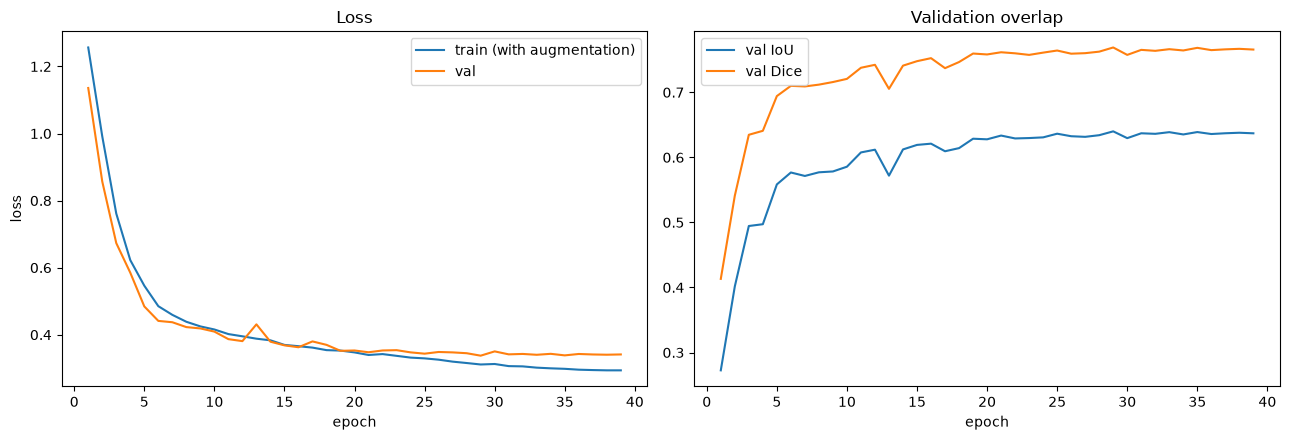

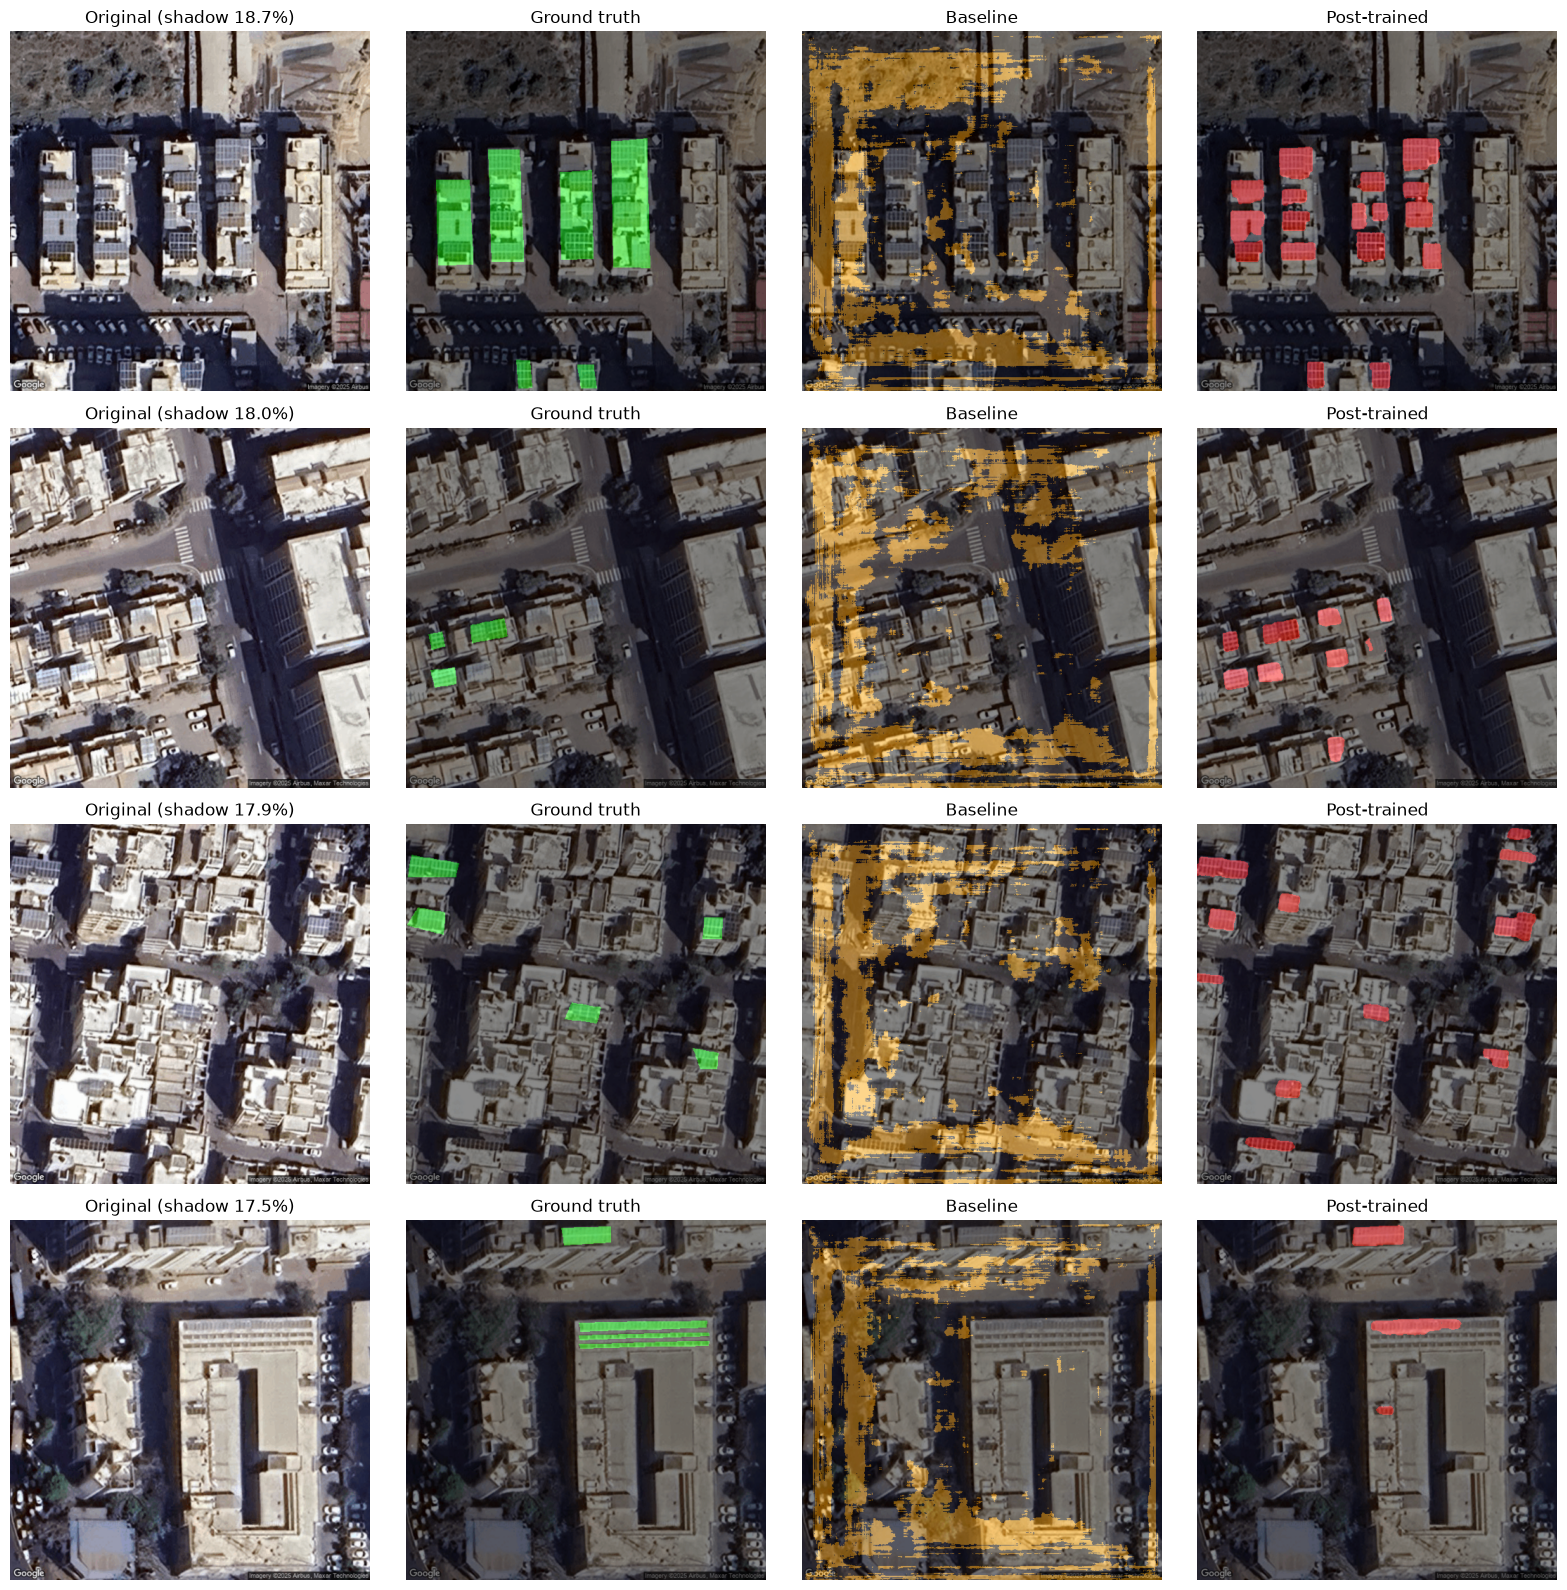

In [12]:
history_df = pd.DataFrame(history)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(history_df["epoch"], history_df["train_loss"], label="train (with augmentation)")
ax[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].set_title("Loss"); ax[0].legend()
ax[1].plot(history_df["epoch"], history_df["val_pixel_iou"], label="val IoU")
ax[1].plot(history_df["epoch"], history_df["val_pixel_dice"], label="val Dice")
ax[1].set_xlabel("epoch"); ax[1].set_title("Validation overlap"); ax[1].legend()
plt.tight_layout(); plt.savefig(os.path.join(VIS_DIR, f"training_curves_{RUN_NAME}.png"), dpi=150, bbox_inches="tight"); plt.show()

shadow_cov = [float(test_ds[i][2].mean()) for i in range(len(test_ds))]
top = np.argsort(shadow_cov)[::-1][:4]
fig, axes = plt.subplots(len(top), 4, figsize=(16, 4 * len(top)))
axes = np.atleast_2d(axes)
for r, idx in enumerate(top):
    img_t, mask_t, _ = test_ds[idx]; base_t, _, _ = baseline_test_ds[idx]
    with torch.no_grad():
        pred_new = (torch.sigmoid(model(img_t.unsqueeze(0).to(DEVICE)).float()) > PRED_THRESHOLD)[0, 0].cpu().numpy().astype(np.uint8)
        pred_old = (torch.sigmoid(baseline_model(base_t.unsqueeze(0).to(DEVICE)).float()) > PRED_THRESHOLD)[0, 0].cpu().numpy().astype(np.uint8)
    rgb_i, _ = load_gt_mask_for(test_ids[idx]); rgb_i = cv2.resize(rgb_i, (IMG_SIZE, IMG_SIZE))
    panels = [(rgb_i, f"Original (shadow {100*shadow_cov[idx]:.1f}%)"), (sa.overlay_mask(rgb_i, mask_t[0].numpy().astype(np.uint8), (0, 255, 0)), "Ground truth"), (sa.overlay_mask(rgb_i, pred_old, (255, 165, 0)), "Baseline"), (sa.overlay_mask(rgb_i, pred_new, (255, 0, 0)), "Post-trained")]
    for c, (im, title) in enumerate(panels):
        axes[r, c].imshow(im); axes[r, c].set_title(title); axes[r, c].axis("off")
plt.tight_layout(); plt.savefig(os.path.join(VIS_DIR, f"shadow_heavy_test_{RUN_NAME}.png"), dpi=150, bbox_inches="tight"); plt.show()